<a href="https://colab.research.google.com/github/luvr1/CCMACLRL_EXERCISES/blob/main/Reyes_Exercise5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 5: Create your own personal face recognition using SVM

## Instructions:

Create a directory in your google drive using this folder structure

```
My Drive
- Images
  - Train
    - Elizer
      - elizerimage1.jpg
      ...
    - Eliza
      - elizaimage1.jpg
      ...
    - Elijah
      - elijahimage1.jpg
      ...
  - Test
    - testimage1.jpg
    ...
```

- Upload 190 images of your self (selfied are recommended) in the Train folder
- Upload 190 images of your partner in the Train folder
- Upload 10 images each of yourself and your partner in the Test Folder (30 images total for each member)
- Use **.png** or **.jpg** or **.jpeg** images files

In [11]:
pip install numpy opencv-python scikit-learn

## Import libraries

In [12]:
import os
import cv2
import numpy as np
from PIL import Image  # PIL is used to load the image
import matplotlib.pyplot as plt

In [16]:
folder_path = '/content/drive/My Drive/Images/Train/'
print(os.listdir(folder_path))

for person in os.listdir(folder_path):
    person_path = os.path.join(folder_path, person)
    if os.path.isdir(person_path):
        image_files = [f for f in os.listdir(person_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        print(f"{person}: {len(image_files)} images")

['Jude', 'Lovely', 'Lawrence']
Jude: 190 images
Lovely: 190 images
Lawrence: 190 images


## Mount Google Drive

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Display one raw image directly from your drive

In [17]:
def displayImage(image_path):
  image = Image.open(image_path)
  plt.imshow(image)
  plt.axis('on')
  plt.show()


## 2. Load the images from your drive and apply preprocessing to your raw images

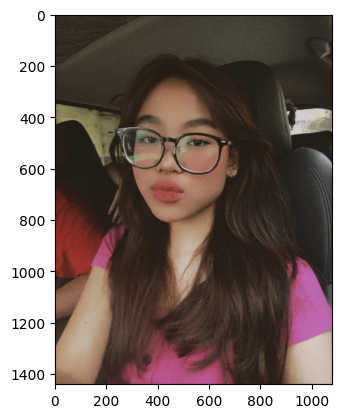

In [18]:
displayImage('/content/drive/My Drive/Images/Train/Lovely/lovelyimage4.jpg')

## 3. Display one pre-processed image from the training set

In [19]:
def load_images_from_folder(folder):
    images = []
    labels = []
    for label, person in enumerate(os.listdir(folder)):
        person_folder = os.path.join(folder, person)
        person_name = os.path.basename(person_folder)
        for filename in os.listdir(person_folder):
            img_path = os.path.join(person_folder, filename)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            img = cv2.resize(img, (250, 250))
            images.append(img.flatten())
            labels.append(person_name)
    return np.array(images), np.array(labels)

In [20]:
images, labels = load_images_from_folder('/content/drive/My Drive/Images/Train')
images.shape
labels.shape
labels

array(['Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
       'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude', 'Jude',
      

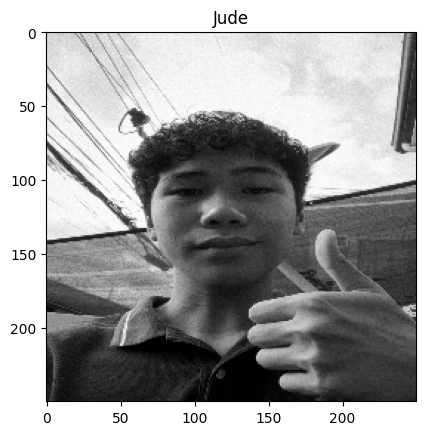

In [21]:
image = images[0].reshape(250,250)
name = labels[0]
plt.imshow(image, cmap="gray")
plt.title(name)
plt.axis('on')
plt.show()


## 4. Display ten pre-processed images from the training set

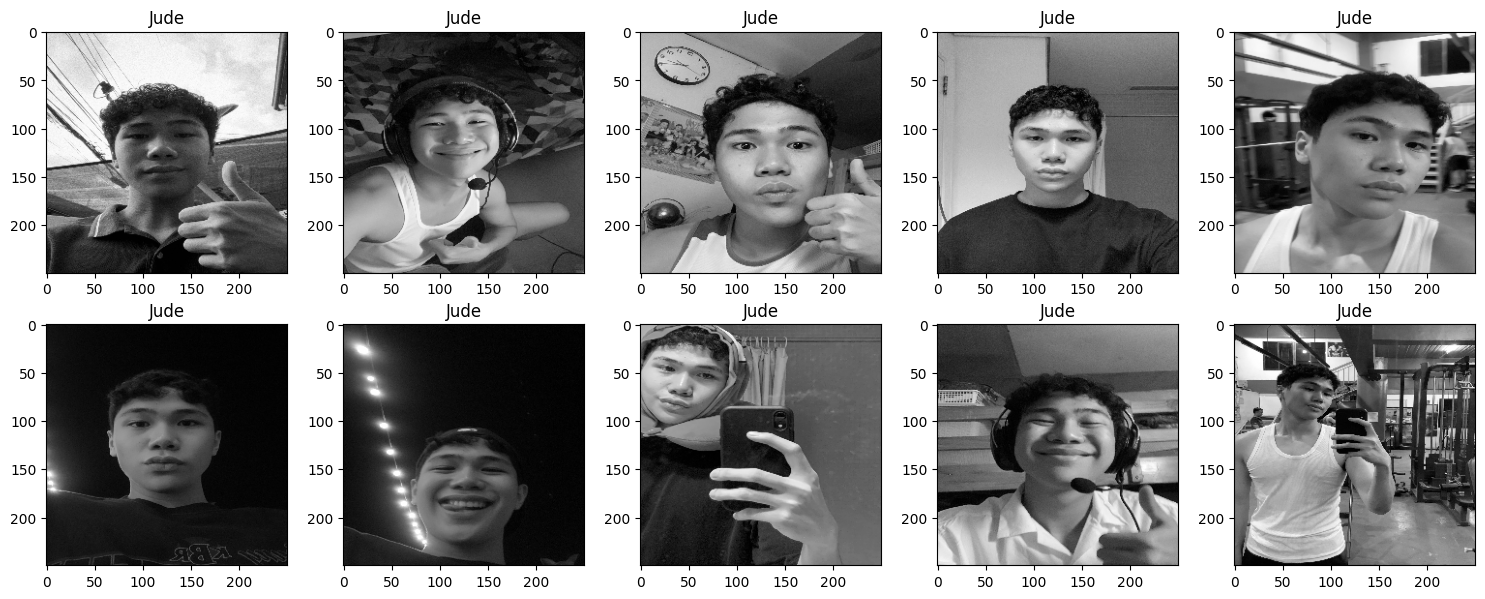

In [22]:
num_faces = 10
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(num_faces):
    image = images[i].reshape(250,250)
    name = labels[i]

    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(name)
    axes[i].axis('on')

plt.tight_layout()
plt.show()


## 5. Split your training data

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [24]:
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

## 6. Train your SVM model

In [25]:
from sklearn import svm

model = svm.SVC(gamma='scale')
model.fit(X_train, y_train)


SVC()

## 7. Evaluate your SVM model

In [26]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 80.70%


## 8. Test your model using images not in your training set

Use your SVM model to predict the label of all of your images in the Test folder

In [27]:
def predict_image(img_path, model):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, (250, 250)).flatten().reshape(1, -1)
    prediction = model.predict(img)
    return prediction

Predicted Label: ['Lovely']


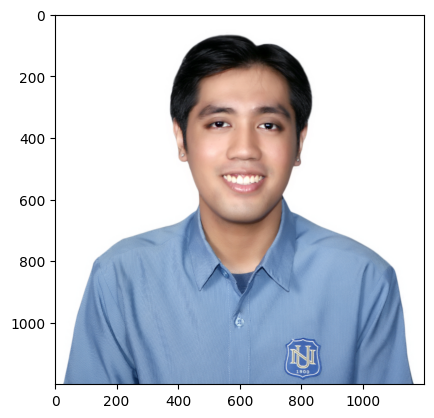

Predicted Label: ['Lovely']


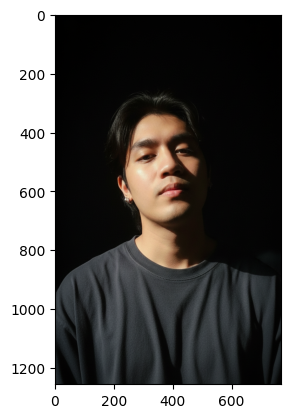

Predicted Label: ['Lovely']


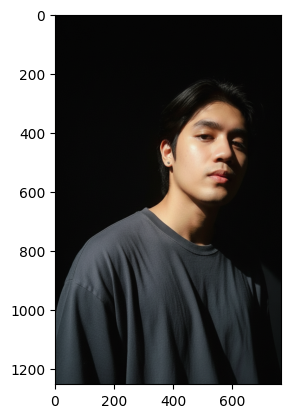

Predicted Label: ['Lovely']


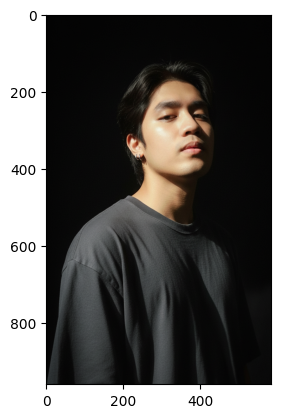

Predicted Label: ['Lovely']


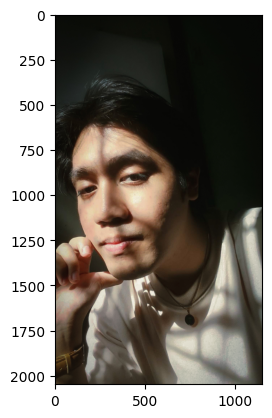

Predicted Label: ['Jude']


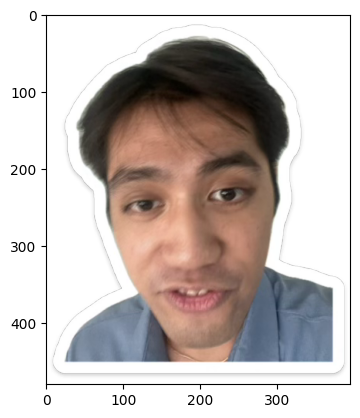

Predicted Label: ['Jude']


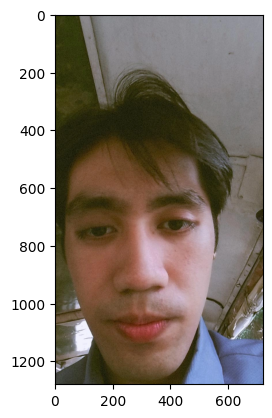

Predicted Label: ['Jude']


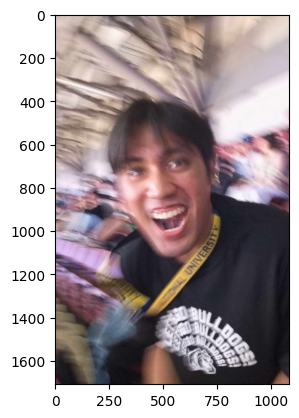

Predicted Label: ['Jude']


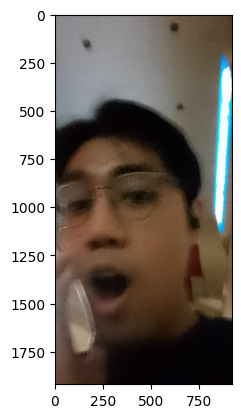

Predicted Label: ['Lovely']


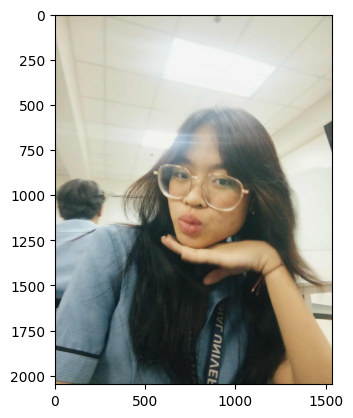

Predicted Label: ['Jude']


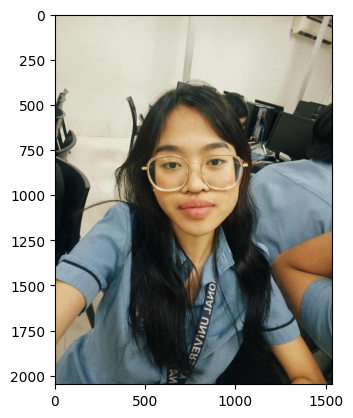

Predicted Label: ['Jude']


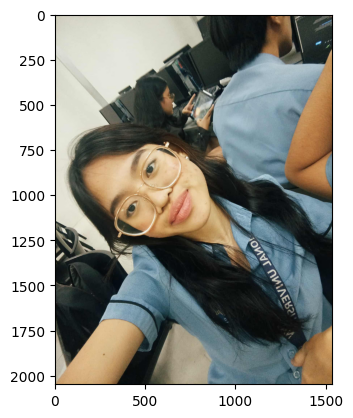

Predicted Label: ['Jude']


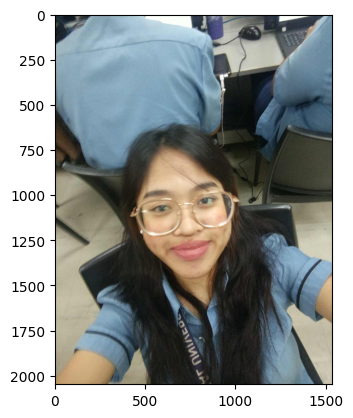

Predicted Label: ['Lovely']


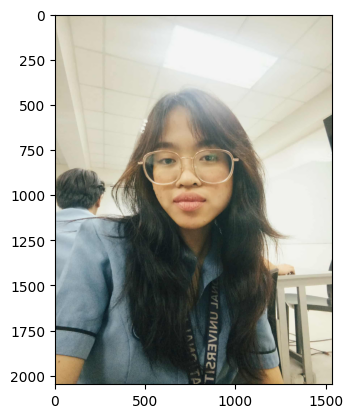

Predicted Label: ['Jude']


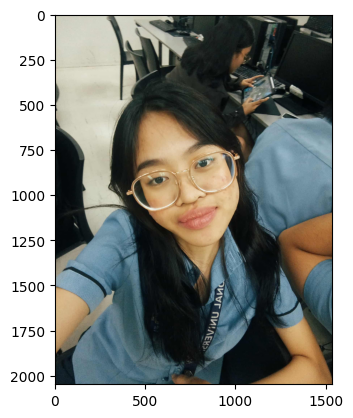

Predicted Label: ['Lovely']


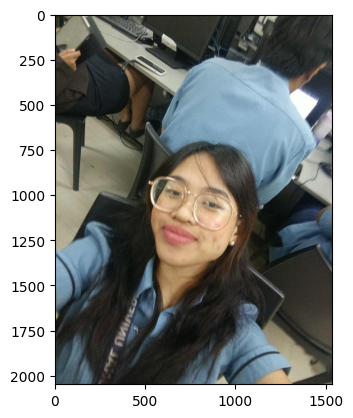

Predicted Label: ['Lovely']


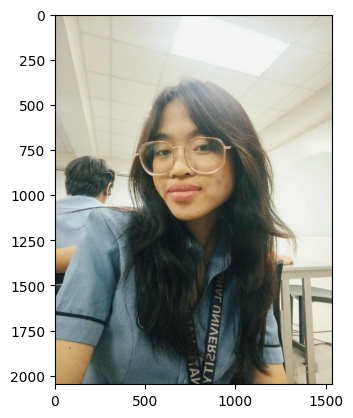

Predicted Label: ['Jude']


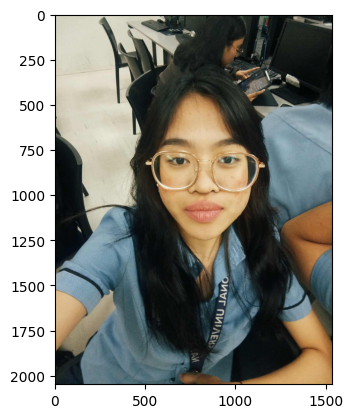

Predicted Label: ['Lovely']


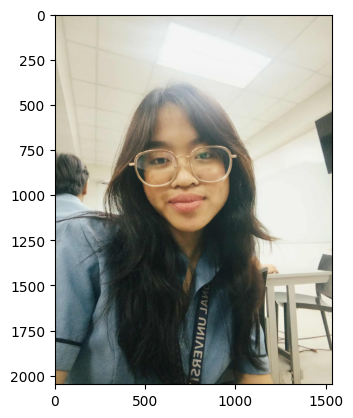

Predicted Label: ['Jude']


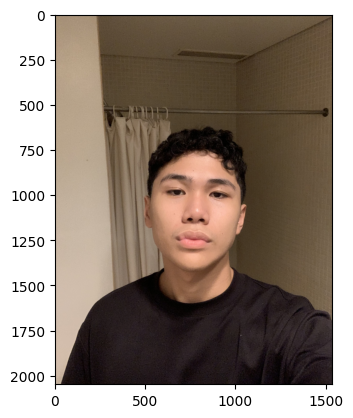

Predicted Label: ['Jude']


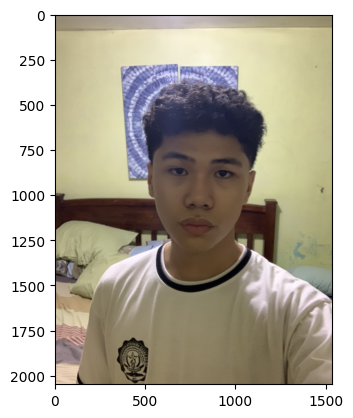

Predicted Label: ['Jude']


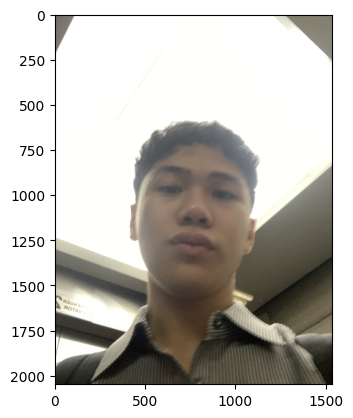

Predicted Label: ['Jude']


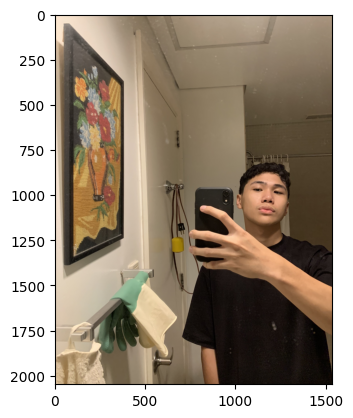

Predicted Label: ['Jude']


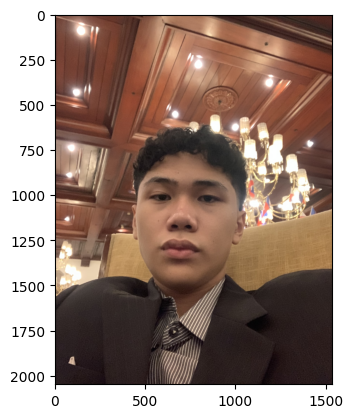

Predicted Label: ['Jude']


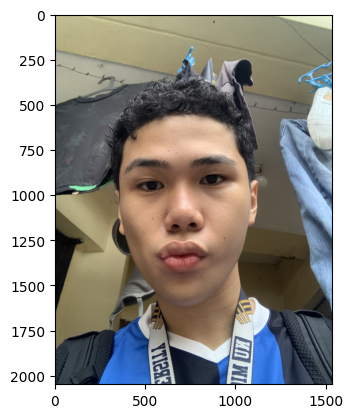

Predicted Label: ['Jude']


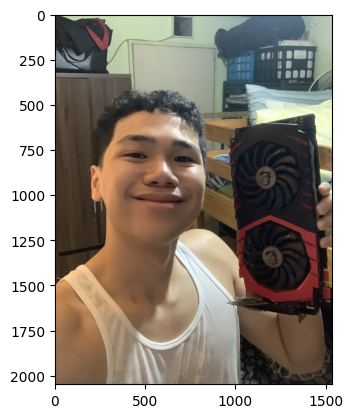

Predicted Label: ['Jude']


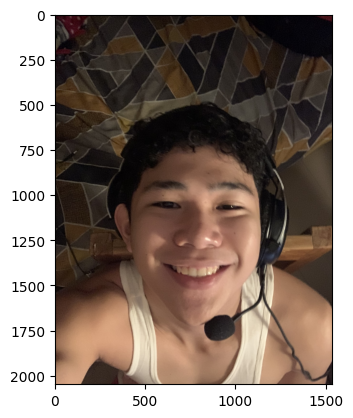

Predicted Label: ['Lawrence']


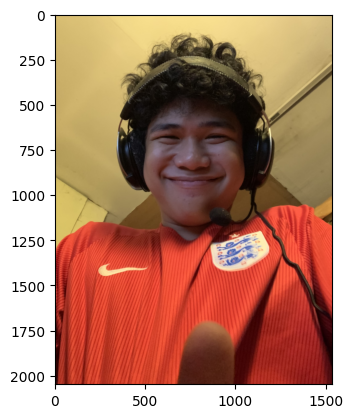

Predicted Label: ['Jude']


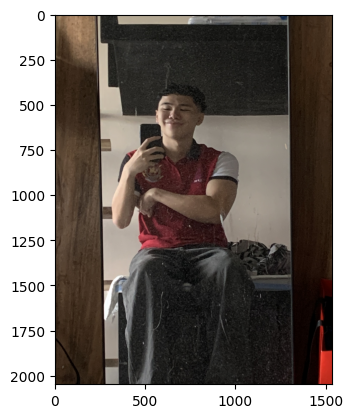

Predicted Label: ['Jude']


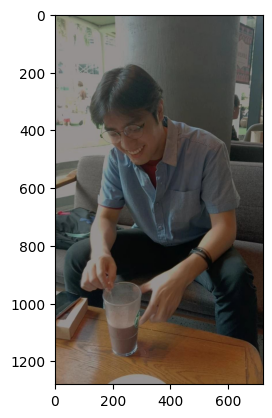

In [28]:
import os

TEST_PATH = '/content/drive/My Drive/Images/Test/' # Define the path to your test images

all_test_images = []
for root, dirs, files in os.walk(TEST_PATH):
  for file in files:
    if file.endswith(".jpg") or file.endswith(".png") or file.endswith(".jpeg"):
      img_path = os.path.join(root, file)
      all_test_images.append(img_path)

if all_test_images:
  for img_path in all_test_images:
    result = predict_image(img_path, model)
    print(f"Predicted Label:", result)
    displayImage(img_path)